# Frozen validation splits

The 24 usable labelled images are assigned to five fixed development folds. Pair 278 and the five unlabelled images are excluded. All 30 source images and the highest-ranked overlap candidates were visually reviewed; no repeated scene was confirmed. No location coordinates were found, so **geographical independence is not established**. See `../splits/README.md` for evidence, limitations and the assignment recipe.

Each original image enters validation exactly once. Roof coverage is spread across folds using a deterministic rank-based allocation, seed 42. Splits are fixed before model training.


In [1]:
from pathlib import Path
import sys

# Allow imports when Jupyter starts in notebooks/ without an editable install.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "roof_utils").is_dir() and (p / "pyproject.toml").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from roof_utils.config import load_paths
PATHS = load_paths(PROJECT_ROOT)

from roof_utils.validation_splits import print_split_summary, show_validation_folds, load_fold
print_split_summary(PATHS)


Plan: v1 | Seed: 42
Scope: Fixed image-level development CV; geographic independence is NOT established. Not an independent final test.
Grouping: Singleton visual scene groups after inspection of 30 images and candidate-pair screening; no repeated building/scene confirmed. These IDs are not known geographic locations.
Excluded: {'278': 'quarantined', '535': 'unlabelled', '537': 'unlabelled', '539': 'unlabelled', '551': 'unlabelled', '553': 'unlabelled'}
Fold 0: train=20, validation=4, roof/valid=13.89%; IDs=121, 241, 328, 417
Fold 1: train=19, validation=5, roof/valid=16.76%; IDs=270, 301, 308, 314, 317
Fold 2: train=19, validation=5, roof/valid=15.31%; IDs=287, 320, 343, 345, 379
Fold 3: train=19, validation=5, roof/valid=15.56%; IDs=284, 300, 303, 315, 324
Fold 4: train=19, validation=5, roof/valid=13.56%; IDs=272, 274, 337, 381, 532
PASS: no split overlap; all 24 eligible images validate exactly once; groups intact; data hashes match.


## Validation images by fold

Each row below is a validation fold. The remaining eligible images form its training set. These are the original prepared images before augmentation.


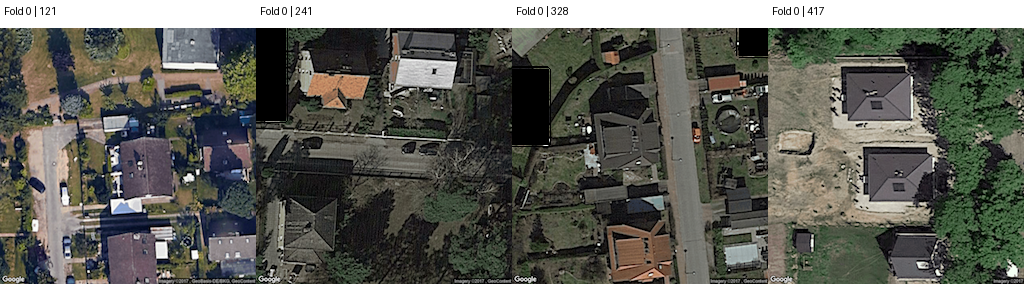

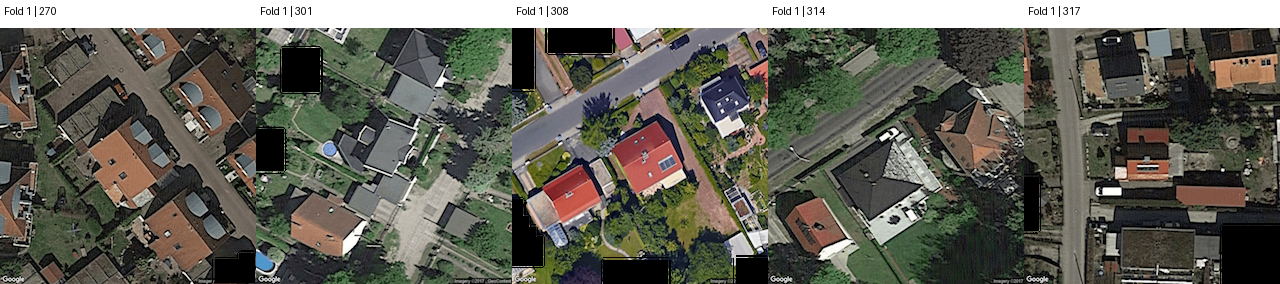

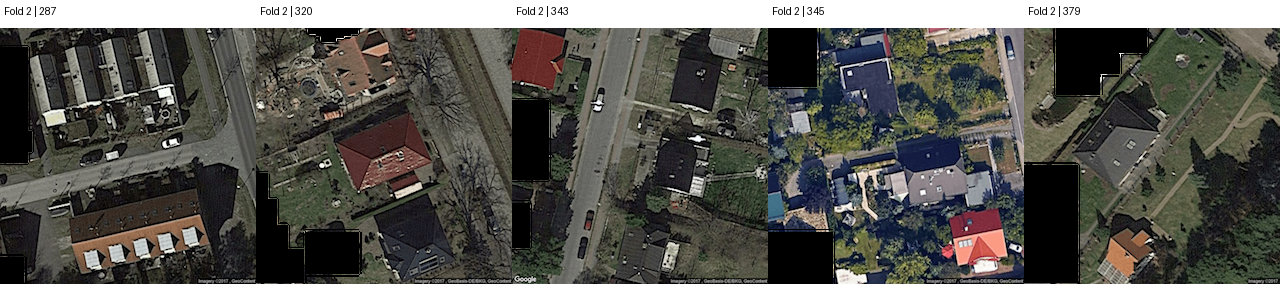

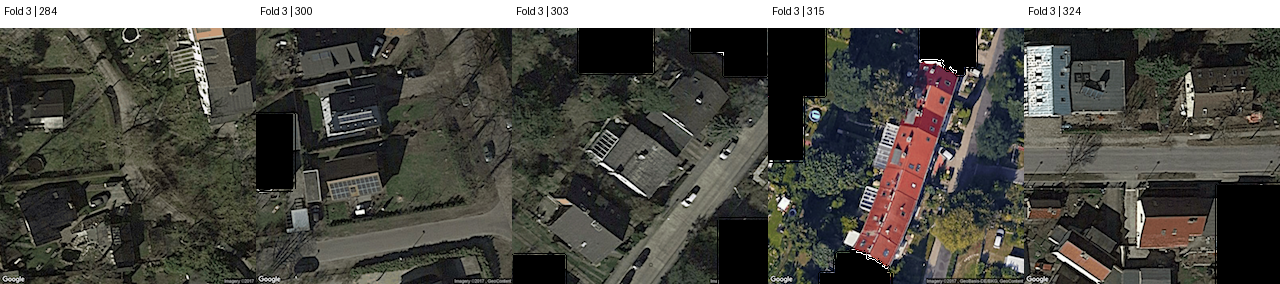

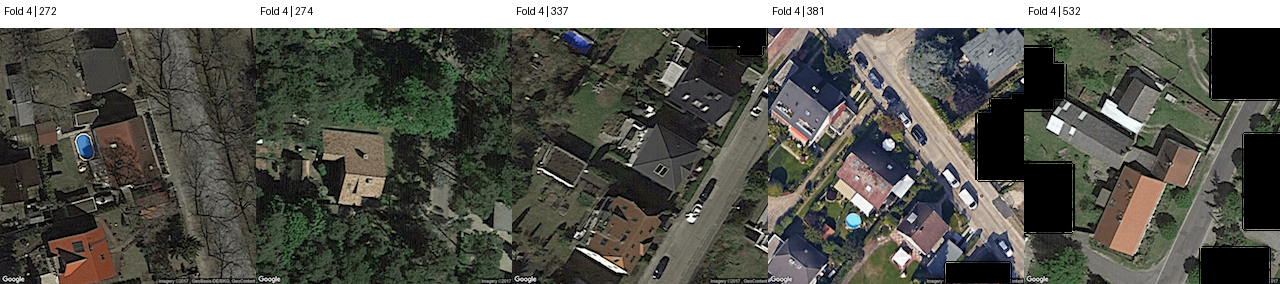

In [2]:
show_validation_folds(PATHS)


## Load the same assignments for every experiment

The loader checks status, groups, coverage and file hashes. If annotations or groups change, review and version a new split plan. Do not reshuffle in response to validation scores.


In [3]:
train_ids, val_ids = load_fold(PATHS, fold=0)
print("Train:", train_ids)
print("Validation:", val_ids)


Train: ['270', '272', '274', '284', '287', '300', '301', '303', '308', '314', '315', '317', '320', '324', '337', '343', '345', '379', '381', '532']
Validation: ['121', '241', '328', '417']
